## Research Questions

The project is guided by three research questions:

####**Research Question 1:** How has reported 311 demand concentration by service request category and city division changed between 2010–2013 and 2022–2025?

####**Research Question 2:** Which high-volume 311 service request categories show different monthly or seasonal patterns between 2010–2013 and 2022–2025?

####**Research Question 3:** Which differences between the early and recent periods can be compared responsibly, and which require caution because of changes in categories, divisions, wards, data coverage, or reporting practices?

## Changes Made Since Milestone 3

In Milestone 3 I wrote that I would not use regression or cross-validation as main methods. I changed
this for Milestone 4 for two reasons.

First, my own Milestone 3 result showed the problem. The seasonal average baseline had a MAPE of 13.39%
but missed the February and December 2025 spikes badly. That told me a model with a trend term was worth
testing, because the baseline can only ever repeat the average of past months.

Second, Milestone 4 requires me to compare my final results against a baseline and to name a final model
and explain why I chose it over other options. That is not possible with only one model.

So the analysis method is the same descriptive comparison as before, with a model comparison added on top.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/CIND 820/"

file_paths = {
    2010: DATA_PATH + "SR2010.csv",
    2011: DATA_PATH + "SR2011.csv",
    2012: DATA_PATH + "SR2012.csv",
    2013: DATA_PATH + "SR2013.csv",
    2022: DATA_PATH + "SR2022.csv",
    2023: DATA_PATH + "SR2023.csv",
    2024: DATA_PATH + "SR2024.csv",
    2025: DATA_PATH + "SR2025.csv"
}

file_paths

{2010: '/content/drive/MyDrive/CIND 820/SR2010.csv',
 2011: '/content/drive/MyDrive/CIND 820/SR2011.csv',
 2012: '/content/drive/MyDrive/CIND 820/SR2012.csv',
 2013: '/content/drive/MyDrive/CIND 820/SR2013.csv',
 2022: '/content/drive/MyDrive/CIND 820/SR2022.csv',
 2023: '/content/drive/MyDrive/CIND 820/SR2023.csv',
 2024: '/content/drive/MyDrive/CIND 820/SR2024.csv',
 2025: '/content/drive/MyDrive/CIND 820/SR2025.csv'}

### 2010

In [ ]:
df_2010 = pd.read_csv(file_paths[2010])

print("2010 file loaded successfully")
print("Shape:", df_2010.shape)
df_2010.head()

2010 file loaded successfully
Shape: (254218, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2010-01-01 00:38:26.0000000,Closed,Intersection,High Park Blvd,Parkside Dr,Parkdale-High Park (13),Road - Sanding / Salting Required,Transportation Services,Road Operations
1,2010-01-01 01:19:18.0000000,Closed,M4T,NaN,NaN,Toronto Centre-Rosedale (27),Water Service Line-Turn On,Toronto Water,District Ops
2,2010-01-01 01:19:48.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops
3,2010-01-01 01:24:18.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops
4,2010-01-01 01:42:26.0000000,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Watermain-Possible Break,Toronto Water,District Ops


### 2011

In [ ]:
df_2011 = pd.read_csv(file_paths[2011])

print("2011 file loaded successfully")
print("Shape:", df_2011.shape)
df_2011.head()

2011 file loaded successfully
Shape: (285333, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2011-01-01 01:04:36.0000000,Closed,M6S,NaN,NaN,Parkdale-High Park (13),Sewer Service Line-Blocked,Toronto Water,District Ops
1,2011-01-01 01:07:28.0000000,Closed,M1N,NaN,NaN,Scarborough Southwest (36),Noise,Municipal Licensing & Standards,District Enforcement
2,2011-01-01 03:19:14.0000000,Closed,M6S,NaN,NaN,Parkdale-High Park (13),Noise,Municipal Licensing & Standards,District Enforcement
3,2011-01-01 03:29:32.0000000,Closed,M1K,NaN,NaN,Scarborough Centre (37),Noise,Municipal Licensing & Standards,District Enforcement
4,2011-01-01 07:40:32.0000000,Closed,M4J,NaN,NaN,Toronto-Danforth (29),Residential: Garbage Bin: Exchange to Small,Solid Waste Management Services,Collections


### 2012

In [ ]:
df_2012 = pd.read_csv(file_paths[2012])

print("2012 file loaded successfully")
print("Shape:", df_2012.shape)
df_2012.head()

2012 file loaded successfully
Shape: (307299, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2012-01-01 00:08:09.0000000,Closed,M6L,NaN,NaN,York South-Weston (12),Hydrant-Damage,Toronto Water,District Ops
1,2012-01-01 00:30:41.0000000,Closed,M1E,NaN,NaN,Scarborough East (43),Permit Inspection,Urban Forestry,Tree Protection and Plan Review
2,2012-01-01 00:36:36.0000000,Closed,M1W,NaN,NaN,Scarborough-Agincourt (40),Publication Request - Transportation,311,Operations
3,2012-01-01 01:27:55.0000000,Closed,M2J,NaN,NaN,Don Valley East (33),Property Standards,Municipal Licensing & Standards,District Enforcement
4,2012-01-01 02:31:02.0000000,Closed,M2N,NaN,NaN,Willowdale (24),Residential Furniture / Not Picked Up,Solid Waste Management Services,Collections


### 2013

In [ ]:
df_2013 = pd.read_csv(file_paths[2013])

print("2013 file loaded successfully")
print("Shape:", df_2013.shape)
df_2013.head()

2013 file loaded successfully
Shape: (385870, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2013-01-01 00:28:37.0000000,Closed,M1B,NaN,NaN,Scarborough-Rouge River (42),Sidewalk - Cleaning,Transportation Services,Road Operations
1,2013-01-01 00:44:18.0000000,Closed,M4K,NaN,NaN,Toronto-Danforth (29),Sidewalk Icy|| Needs Sand/Salt,Transportation Services,Road Operations
2,2013-01-01 01:04:28.0000000,Closed,M6M,NaN,NaN,York South-Weston (12),STRAY AT LARGE,Municipal Licensing & Standards,Toronto Animal Services
3,2013-01-01 01:12:13.0000000,Closed,M2R,NaN,NaN,Willowdale (23),Noise,Municipal Licensing & Standards,District Enforcement
4,2013-01-01 02:12:10.0000000,Closed,M9C,NaN,NaN,Etobicoke Centre (03),Boulevard - Plough Damage,Transportation Services,Road Operations


### Fixing How the Recent Files Are Loaded

In Milestone 3 I loaded the 2022 to 2025 files with `on_bad_lines="skip"`, because pandas outputted a line stating "Expected 9 fields, saw 10" or something similar for the recent years. I assumed from the error message that this was one bad row per file. It was not!! The error only names the **first** bad line. When I checked the row counts properly I found that 134,296 rows were being deleted across the four recent files, which is 7.5% of the recent period.

Unlike the 2010 to 2013 files, any value containing a comma splits into an extra column. Almost every deleted row was the same division: `Parks, Forestry & Recreation`, renamed to `Environment, Climate & Forestry` in 2025. Both names contain a comma, so an entire city division was being removed from my analysis. Rather than skipping those rows, I repair them by joining the split Division value back together.

In [ ]:
# Loading the recent files without losing rows.
# A line with 10 fields means the Division value contained a comma and split into two pieces,
# so I join fields 7 and 8 back together instead of throwing the row away.

column_names = [
    "Creation Date", "Status", "First 3 Chars of Postal Code",
    "Intersection Street 1", "Intersection Street 2", "Ward",
    "Service Request Type", "Division", "Section"
]


def load_recent_file(path):
    text = open(path, encoding="latin1").read()

    lines = [line.rstrip("\r") for line in text.split("\n")]
    lines = [line for line in lines if line.strip() != ""]

    good_rows = []
    repaired_count = 0

    for line in lines[1:]:                 # skipping the header row
        fields = line.split(",")

        if len(fields) == 10:              # the Division split into two pieces
            fields = fields[:7] + [fields[7] + "," + fields[8]] + [fields[9]]
            repaired_count = repaired_count + 1

        if len(fields) == 9:
            good_rows.append(fields)

    print("Rows loaded:", len(good_rows), "| Rows repaired:", repaired_count)
    return pd.DataFrame(good_rows, columns=column_names)

print("Repair function defined.")

Repair function defined.


### 2022

In [ ]:
df_2022 = load_recent_file(file_paths[2022])

print("2022 file loaded successfully")
print("Shape:", df_2022.shape)
df_2022.head()

Rows loaded: 442950 | Rows repaired: 35581
2022 file loaded successfully
Shape: (442950, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2022-01-01 00:12:24.0000000,Completed,M1E,,,Scarborough-Rouge Park (25),Fireworks,Municipal Licensing & Standards,Parks Enforcement
1,2022-01-01 00:20:34.0000000,Completed,M9N,,,York South-Weston (05),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
2,2022-01-01 00:31:00.0000000,Completed,M3J,,,York Centre (06),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
3,2022-01-01 00:31:28.0000000,Completed,M3H,,,York Centre (06),Fireworks,Municipal Licensing & Standards,Parks Enforcement
4,2022-01-01 00:37:50.0000000,Completed,M9C,,,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement


### 2023

In [ ]:
df_2023 = load_recent_file(file_paths[2023])

print("2023 file loaded successfully")
print("Shape:", df_2023.shape)
df_2023.head()

Rows loaded: 414282 | Rows repaired: 28307
2023 file loaded successfully
Shape: (414282, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2023-01-01 00:10:38.0000000,Completed,M8W,,,Etobicoke-Lakeshore (03),Sewer Service Line-Blocked,Toronto Water,District Ops
1,2023-01-01 00:31:00.0000000,Completed,M6K,,,Parkdale-High Park (04),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
2,2023-01-01 00:32:11.0000000,Completed,M3N,,,Humber River-Black Creek (07),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
3,2023-01-01 00:42:35.0000000,Completed,M9N,,,York South-Weston (05),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
4,2023-01-01 00:49:51.0000000,Completed,M4S,,,Toronto-St. Paul's (12),Unreasonable and Persistent Noise,Municipal Licensing & Standards,Bylaw Enforcement


### 2024

In [ ]:
df_2024 = load_recent_file(file_paths[2024])

print("2024 file loaded successfully")
print("Shape:", df_2024.shape)
df_2024.head()

Rows loaded: 437043 | Rows repaired: 34219
2024 file loaded successfully
Shape: (437043, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2024-01-01 00:10:57.0000000,Completed,M4A,,,Beaches-East York (19),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
1,2024-01-01 00:20:03.0000000,Completed,M8W,,,Etobicoke-Lakeshore (03),Fireworks,Municipal Licensing & Standards,Parks Enforcement
2,2024-01-01 00:29:48.0000000,Unknown,M6C,,,Toronto-St. Paul's (12),Business Complaint,Municipal Licensing & Standards,Business Licensing Enforcement
3,2024-01-01 00:37:32.0000000,Unknown,M1R,,,Scarborough Centre (21),Unknown - MLSBLEMMVN,Unknown,Unknown
4,2024-01-01 00:52:35.0000000,Completed,M3M,,,York Centre (06),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement


### 2025

In [ ]:
df_2025 = load_recent_file(file_paths[2025])

print("2025 file loaded successfully")
print("Shape:", df_2025.shape)
df_2025.head()

Rows loaded: 500269 | Rows repaired: 36189
2025 file loaded successfully
Shape: (500269, 9)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2025-01-01 00:01:05.0000000,Completed,M8Y,,,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services
1,2025-01-01 00:02:16.0000000,Completed,M5V,,,Spadina-Fort York (10),Amplified Sound or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement
2,2025-01-01 00:14:46.0000000,Cancelled,M1V,,,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services
3,2025-01-01 00:16:28.0000000,Completed,M1V,,,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right of Way (ROW)
4,2025-01-01 00:25:00.0000000,Completed,M9R,,,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement


In [ ]:
# Checking that the repair recovered the rows I expected

for year in [2022, 2023, 2024, 2025]:
    frame = {2022: df_2022, 2023: df_2023, 2024: df_2024, 2025: df_2025}[year]
    print(year, "->", len(frame), "rows")

print()
print("Divisions found in the recent files after the repair:")
print(pd.concat([df_2022, df_2023, df_2024, df_2025])["Division"].value_counts())

2022 -> 442950 rows
2023 -> 414282 rows
2024 -> 437043 rows
2025 -> 500269 rows

Divisions found in the recent files after the repair:
Division
Solid Waste Management Services             608840
Municipal Licensing & Standards             440451
Transportation Services                     426837
Toronto Water                               138202
Parks, Forestry & Recreation                 98077
Environment, Climate & Forestry              36174
311                                          29937
Unknown                                      14544
Parks and Recreation                          1437
Solid Waste Management Services,Transfer        45
Name: count, dtype: int64


### Source Year

In [ ]:
df_2010["Source Year"] = 2010
df_2011["Source Year"] = 2011
df_2012["Source Year"] = 2012
df_2013["Source Year"] = 2013

df_2022["Source Year"] = 2022
df_2023["Source Year"] = 2023
df_2024["Source Year"] = 2024
df_2025["Source Year"] = 2025

In [ ]:
df_2025.head() #source year is column 10

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,Source Year
0,2025-01-01 00:01:05.0000000,Completed,M8Y,,,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services,2025
1,2025-01-01 00:02:16.0000000,Completed,M5V,,,Spadina-Fort York (10),Amplified Sound or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement,2025
2,2025-01-01 00:14:46.0000000,Cancelled,M1V,,,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services,2025
3,2025-01-01 00:16:28.0000000,Completed,M1V,,,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right of Way (ROW),2025
4,2025-01-01 00:25:00.0000000,Completed,M9R,,,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement,2025


In [ ]:
# The years combined into one dataframe

df = pd.concat(
    [df_2010, df_2011, df_2012, df_2013, df_2022, df_2023, df_2024, df_2025],
    ignore_index=True # combining all rows w/out repeating row numbers, new row index
)

print("Combined dataframe created successfully.")
print("Shape:", df.shape)
df.head()

Combined dataframe created successfully.
Shape: (3027264, 10)


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,Source Year
0,2010-01-01 00:38:26.0000000,Closed,Intersection,High Park Blvd,Parkside Dr,Parkdale-High Park (13),Road - Sanding / Salting Required,Transportation Services,Road Operations,2010
1,2010-01-01 01:19:18.0000000,Closed,M4T,NaN,NaN,Toronto Centre-Rosedale (27),Water Service Line-Turn On,Toronto Water,District Ops,2010
2,2010-01-01 01:19:48.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops,2010
3,2010-01-01 01:24:18.0000000,Cancelled,M1T,NaN,NaN,Scarborough-Agincourt (40),Water Service Line-Leaking,Toronto Water,District Ops,2010
4,2010-01-01 01:42:26.0000000,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Watermain-Possible Break,Toronto Water,District Ops,2010


In [ ]:
# The repaired files were read as text, so the blank intersection fields are empty strings
# rather than NaN. I convert them so my missing value checks below still work correctly.

for column in ["First 3 Chars of Postal Code", "Intersection Street 1",
               "Intersection Street 2", "Ward", "Service Request Type",
               "Division", "Section", "Status"]:
    df[column] = df[column].astype(str).str.strip()
    df[column] = df[column].replace({"": np.nan, "nan": np.nan})

print("Blank values converted to NaN.")
df.shape

Blank values converted to NaN.


(3027264, 10)

In [ ]:
# Early vs Recent Period

df["Period"] = np.where(
    df["Source Year"].isin([2010, 2011, 2012, 2013]),
    "Early Period (2010-2013)",
    "Recent Period (2022-2025)"
)

df[["Source Year", "Period"]].head()

,Source Year,Period
0,2010,Early Period (2010-2013)
1,2010,Early Period (2010-2013)
2,2010,Early Period (2010-2013)
3,2010,Early Period (2010-2013)
4,2010,Early Period (2010-2013)


In [ ]:
# number of rows in each period
df["Period"].value_counts()

,count
Period,
Recent Period (2022-2025),1794544
Early Period (2010-2013),1232720


##### The dataset total of both early and recent periods contain 3,027,264 records. The early period from 2010–2013 contains 1,794,544 records, while the recent period from 2022–2025 contains 1,232,720 records. This shows that the recent period has a higher number of reported 311 service requests. However, this should be interpreted as reported demand only, not as proof that actual municipal service need increased.

In [ ]:
# rows in each source year
df["Source Year"].value_counts().sort_index()

,count
Source Year,
2010,254218
2011,285333
2012,307299
2013,385870
2022,442950
2023,414282
2024,437043
2025,500269


##### The combined dataset includes eight full years of Toronto 311 customer-initiated service request data. The number of records generally increases across the early years, from 254,218 records in 2010 to 385,870 records in 2013. In the recent period, 2025 has the highest number of records with 464,080 requests. These counts help show the size of each yearly file before moving into missing value checks, date cleaning, and exploratory analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3027264 entries, 0 to 3027263
Data columns (total 11 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Creation Date                 object
 1   Status                        object
 2   First 3 Chars of Postal Code  object
 3   Intersection Street 1         object
 4   Intersection Street 2         object
 5   Ward                          object
 6   Service Request Type          object
 7   Division                      object
 8   Section                       object
 9   Source Year                   int64 
 10  Period                        object
dtypes: int64(1), object(10)
memory usage: 254.1+ MB


In [ ]:
# need to make creation date to datetime format
df["Creation Date"] = pd.to_datetime(df["Creation Date"], errors="coerce")

In [ ]:
df["Creation Date"].dtype

dtype('<M8[ns]')

##### The Creation Date column was originally read as an object, which means Python treated it as text. I converted it to datetime format so that I can create time-based variables such as year, month, weekday, and season. I used "errors=coerce" so that any date values that could not be converted would become missing values instead of stopping the notebook. I used Chatgpt to help me figure out how to convert the missing values by showing it the steps I had already taken and what I needed. I'm asking panda to not crash if it finds a value it cannot convert. Instead turn it into a missing date value.

In [ ]:
df["Creation Date"].isna().sum()

np.int64(0)

#### After converting the Creation Date column to datetime format, there were 0 missing date values. This means all Creation Date values were successfully converted and can be used to create year, month, weekday, and season variables.

In [ ]:
# want to pull out the specific, month, year, period, etc...

df["Year"] = df["Creation Date"].dt.year
df["Month"] = df["Creation Date"].dt.month
df["Month Name"] = df["Creation Date"].dt.month_name()
df["Weekday"] = df["Creation Date"].dt.day_name()

df[["Creation Date", "Year", "Month", "Month Name", "Weekday", "Source Year", "Period"]].head()

,Creation Date,Year,Month,Month Name,Weekday,Source Year,Period
0,2010-01-01 00:38:26,2010,1,January,Friday,2010,Early Period (2010-2013)
1,2010-01-01 01:19:18,2010,1,January,Friday,2010,Early Period (2010-2013)
2,2010-01-01 01:19:48,2010,1,January,Friday,2010,Early Period (2010-2013)
3,2010-01-01 01:24:18,2010,1,January,Friday,2010,Early Period (2010-2013)
4,2010-01-01 01:42:26,2010,1,January,Friday,2010,Early Period (2010-2013)


In [ ]:
# Checking to make sure the year from Creation date does infact match the Source Year
# 23,027,264is the total number of rows from all periods, so there's notne that do not match!
df["Year Match"] = df["Year"] == df["Source Year"]
df["Year Match"].value_counts()

,count
Year Match,
True,3027264


In [ ]:
# Seasons by month count

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)

df[["Creation Date", "Month", "Month Name", "Season"]].head()

,Creation Date,Month,Month Name,Season
0,2010-01-01 00:38:26,1,January,Winter
1,2010-01-01 01:19:18,1,January,Winter
2,2010-01-01 01:19:48,1,January,Winter
3,2010-01-01 01:24:18,1,January,Winter
4,2010-01-01 01:42:26,1,January,Winter


In [ ]:
df["Season"].value_counts()

,count
Season,
Summer,885841
Fall,740437
Spring,739238
Winter,661748


The Season column was created from the Month column. Winter includes December, January, and February; Spring includes March, April, and May; Summer includes June, July, and august; and Fall includes September, October, and November. This variable is needed for the seasonal part of the analysis because RQ2 compares monthly and seasonal patterns between the early and recent periods.

In [ ]:
#ordering them differently
df["Season"].value_counts().reindex(["Spring", "Summer", "Fall", "Winter"])

,count
Season,
Spring,739238
Summer,885841
Fall,740437
Winter,661748


##### Summer has the highest number of reported 311 service requests with 837,429 records, followed by Fall with 718,419 records, Spring with 704,238 records, and lastly Winter with 653,416 records. This gives an early indication that reported 311 activity is not evenly distributed across seasons, which connects to RQ2 on monthly and seasonal patterns.

In [ ]:
df.isna().sum()

,0
Creation Date,0
Status,0
First 3 Chars of Postal Code,0
Intersection Street 1,2655940
Intersection Street 2,2658065
Ward,0
Service Request Type,0
Division,0
Section,0
Source Year,0


##### The missing value check showed that most fields used in the main analysis have 0 missing values, including Creation Date, Status, Ward, Service Request Type, Division, Section, Source Year, Period, Year, Month, Month Name, Weekday, and Season. The main missingness issue is with the two intersection street fields. Intersection Street 1 has 2,549,187 missing values and Intersection Street 2 has 2,551,174 missing values. Because these fields are not central to the main research questions, they will not be used as primary analysis variables. This supports the decision to focus on service request type, division, time period, month, season, and status instead.

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percent": (df.isna().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Count,Missing Percent
Creation Date,0,0.00
Status,0,0.00
First 3 Chars of Postal Code,0,0.00
Intersection Street 1,2655940,87.73
Intersection Street 2,2658065,87.80
Ward,0,0.00
Service Request Type,0,0.00
Division,0,0.00
Section,0,0.00
Source Year,0,0.00


intersection street names being missing makes sense. THis is for privacy and safety issues to the civillians entering reports, to protect their identity.

In [ ]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

2318


In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows.shape[0])
duplicate_rows.head(10)

3810


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,Source Year,Period,Year,Month,Month Name,Weekday,Year Match,Season
657,2010-01-04 10:01:54,Closed,M4J,NaN,NaN,Toronto-Danforth (29),All / White Goods / Pick Up Request,Solid Waste Management Services,Collections,2010,Early Period (2010-2013),2010,1,January,Monday,True,Winter
658,2010-01-04 10:01:54,Closed,M4J,NaN,NaN,Toronto-Danforth (29),All / White Goods / Pick Up Request,Solid Waste Management Services,Collections,2010,Early Period (2010-2013),2010,1,January,Monday,True,Winter
47008,2010-03-30 11:33:40,Closed,M5P,NaN,NaN,St. Paul's (21),Water Service Line-No Water,Toronto Water,District Ops,2010,Early Period (2010-2013),2010,3,March,Tuesday,True,Spring
47009,2010-03-30 11:33:40,Closed,M5P,NaN,NaN,St. Paul's (21),Water Service Line-No Water,Toronto Water,District Ops,2010,Early Period (2010-2013),2010,3,March,Tuesday,True,Spring
75243,2010-05-12 08:31:40,Cancelled,Intersection,Dufferin St,College St,Davenport (18),Traffic Signal Maintenance,Transportation Services,TMC,2010,Early Period (2010-2013),2010,5,May,Wednesday,True,Spring
75244,2010-05-12 08:31:40,Cancelled,Intersection,Dufferin St,College St,Davenport (18),Traffic Signal Maintenance,Transportation Services,TMC,2010,Early Period (2010-2013),2010,5,May,Wednesday,True,Spring
370321,2011-06-08 21:28:52,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Storm Clean Up,Urban Forestry,Forestry Operations,2011,Early Period (2010-2013),2011,6,June,Wednesday,True,Summer
370322,2011-06-08 21:28:52,Closed,M1K,NaN,NaN,Scarborough Southwest (35),Storm Clean Up,Urban Forestry,Forestry Operations,2011,Early Period (2010-2013),2011,6,June,Wednesday,True,Summer
387911,2011-06-28 16:01:02,Closed,M1B,NaN,NaN,Scarborough-Rouge River (42),Residential Furniture / Not Picked Up,Solid Waste Management Services,Collections,2011,Early Period (2010-2013),2011,6,June,Tuesday,True,Summer
387912,2011-06-28 16:01:02,Closed,M1B,NaN,NaN,Scarborough-Rouge River (42),Residential Furniture / Not Picked Up,Solid Waste Management Services,Collections,2011,Early Period (2010-2013),2011,6,June,Tuesday,True,Summer


###### The duplicate check found 2,318 extra duplicate rows in the combined dataset. When all rows involved in duplicate groups were displayed, including both the original records and repeated records, 3,810 rows were seen. I cannot fully confirm whether every duplicate is a true data issue or a repeated report with identical information. The duplicate count is very small compared to the full dataset of 3,027,264 records, so it it will only slightly affect request counts, rankings, and percentage shares.

In [ ]:
duplicate_percent = (duplicate_count / len(df)) * 100
print("Duplicate percentage:", round(duplicate_percent, 2), "%")

Duplicate percentage: 0.08 %


#### The combined dataset has 2,318 extra duplicate rows, which represents 0.08% of the full dataset.

In [ ]:
unique_counts = df[
    [
        "Status",
        "First 3 Chars of Postal Code",
        "Ward",
        "Service Request Type",
        "Division",
        "Section",
        "Source Year",
        "Period",
        "Month Name",
        "Weekday",
        "Season"
    ]
].nunique().sort_values(ascending=False)

unique_counts

#two things to note,
#1. 970 different service request types across Toronto that are or were being used
#2. there are 69 wards within the dataset that is covered

,0
Service Request Type,990
First 3 Chars of Postal Code,101
Ward,69
Section,28
Division,12
Month Name,12
Status,9
Source Year,8
Weekday,7
Season,4


###### There are 970 unique Service Request Type values, meaning caution is needed. It also supports why I should focus on top categories, rankings, percentage shares, and period comparisons instead of trying to interpret every single request type. As well, there are 69 unique Ward values across the combined dataset. This makes sense because the early and recent periods use different ward structures. This will supports my decision to treat ward-level comparisons cautiously.

In [ ]:
print("Earliest date:", df["Creation Date"].min())
print("Latest date:", df["Creation Date"].max())

#so the full data range is from January 1 2010 to December 31, 2025
# excluding data from Jan 1, 2014 to Dec 31, 2021

Earliest date: 2010-01-01 00:38:26
Latest date: 2025-12-31 23:59:32


In [ ]:
date_range_by_period = df.groupby("Period")["Creation Date"].agg(["min", "max"])
date_range_by_period

# Jan 1, 2010 to Dec 31, 2013
# Jan 1, 2022 to Dec 31, 2025

,min,max
Period,,
Early Period (2010-2013),2010-01-01 00:38:26,2013-12-31 23:24:39
Recent Period (2022-2025),2022-01-01 00:12:24,2025-12-31 23:59:32


### Exploratory Data Analysis

In [ ]:
status_counts = df["Status"].value_counts()
status_counts

,count
Status,
Completed,1375561
Closed,1186041
Cancelled,272020
In Progress,87966
New,69357
Unknown,23698
Initiated,8430
In-progress,4107
In-Progress,84


#### Status Distribution Results

##### The Status distribution shows that most records are marked as Completed or Closed. Completed has 1,322,048 records, while Closed has 1,184,993 records. Cancelled is the next largest status category with 267,053 records. The remaining status categories are much smaller. This check also showed a minor formatting issue in the Status field because there are three "in progress" columns just written differently. In Progress, In-progress, and In-Progress appear as separate values. These likely refer to the same general status but are treated as separate categories because of differences in capitalization and punctuation. Since Status is not the main focus of the research questions, I documented this as a data quality issue instead of making it a main analysis variable.

In [ ]:
status_summary = pd.DataFrame({
    "Count": df["Status"].value_counts(),
    "Percent": (df["Status"].value_counts() / len(df) * 100).round(2)
})

status_summary

#largest category is completed at 45.38%, followed by closed at 40.57%, and then cancelled at 9.17%

,Count,Percent
Status,,
Completed,1375561,45.44
Closed,1186041,39.18
Cancelled,272020,8.99
In Progress,87966,2.91
New,69357,2.29
Unknown,23698,0.78
Initiated,8430,0.28
In-progress,4107,0.14
In-Progress,84,0.00


In [ ]:
# Service Types: Top 15

top_service_types = df["Service Request Type"].value_counts().head(15)
top_service_types

,count
Service Request Type,
Property Standards,94487
Residential Furniture / Not Picked Up,83812
General Pruning,81628
Sewer Service Line-Blocked,71653
Res / Garbage / Not Picked Up,66825
Injured - Wildlife,64628
Residential: Bin: Repair or Replace Lid,62759
Res / Recycle / Not Picked Up,57951
Res / Organic Green Bin / Not Picked Up,57450


In [ ]:
# Service Type by percentage

top_service_summary = pd.DataFrame({
    "Count": df["Service Request Type"].value_counts().head(15),
    "Percent": (df["Service Request Type"].value_counts().head(15) / len(df) * 100).round(2)
})

top_service_summary

,Count,Percent
Service Request Type,,
Property Standards,94487,3.12
Residential Furniture / Not Picked Up,83812,2.77
General Pruning,81628,2.70
Sewer Service Line-Blocked,71653,2.37
Res / Garbage / Not Picked Up,66825,2.21
Injured - Wildlife,64628,2.13
Residential: Bin: Repair or Replace Lid,62759,2.07
Res / Recycle / Not Picked Up,57951,1.91
Res / Organic Green Bin / Not Picked Up,57450,1.90


##### The top 15 Service Request Type table shows that Property Standards is the most common request type in the combined dataset, with 94,487 records, or 3.24% of all records. Residential Furniture / Not Picked Up is the second largest category at 2.88%, followed by Sewer Service Line-Blocked at 2.46%. One important finding is that even the largest service request type only makes up a small share of the full dataset. This shows that reported 311 demand is spread across many categories rather than being dominated by one single request type. This supports the use of rankings and percentage shares for RQ1 because raw counts alone do not fully show how concentrated or spread out reported demand is.

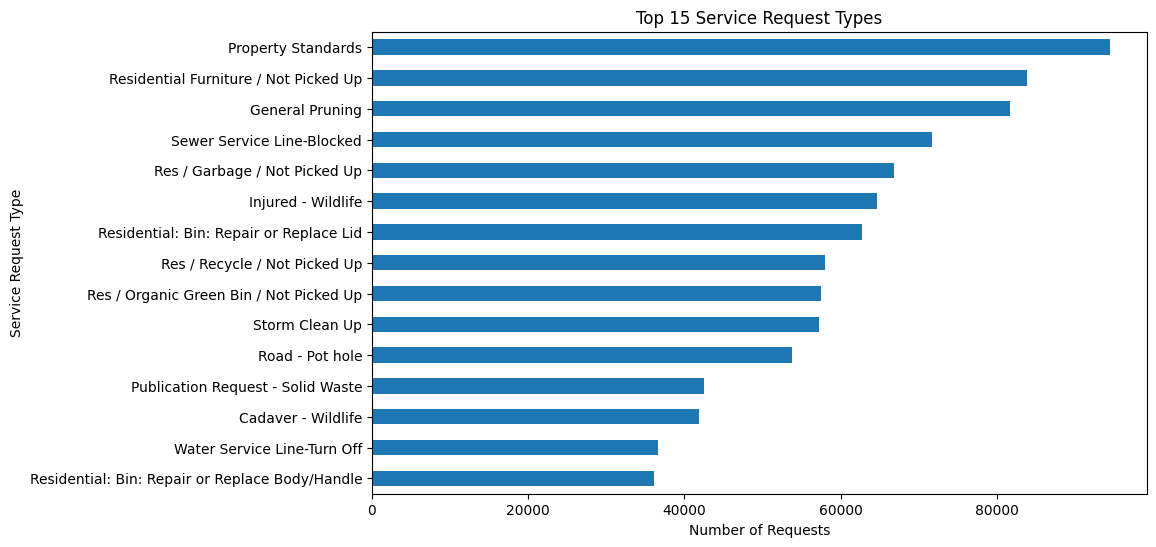

In [ ]:
#chart of top 15 service request types

plt.figure(figsize=(10, 6))
top_service_types.sort_values().plot(kind="barh") #kind = barh creates a horizontal bar chart
plt.title("Top 15 Service Request Types")
plt.xlabel("Number of Requests")
plt.ylabel("Service Request Type")
plt.show()

###### The bar chart shows the top 15 Service Request Type categories in the combined dataset. Property Standards has the highest number of requests, followed by Residential Furniture / Nt Picked Up. The chart helps show which categories appear most often in the selected Toronto 311 data. This supports RQ1 because it shows reported demand concentration by service request category. However, this chart combines the early and recent periods, so it does not yet show whether the top categories changed over time. The next step willcompare service request types by period.

In [ ]:
top_service_by_period = (
    df.groupby(["Period", "Service Request Type"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Period", "Count"], ascending=[True, False])
)

top_service_by_period.head(30)

,Period,Service Request Type,Count
319,Early Period (2010-2013),Residential Furniture / Not Picked Up,51560
256,Early Period (2010-2013),Property Standards,49259
389,Early Period (2010-2013),Sewer Service Line-Blocked,42613
133,Early Period (2010-2013),General Pruning,34210
272,Early Period (2010-2013),Res / Garbage / Not Picked Up,32568
295,Early Period (2010-2013),Res / Organic Bin / Replace Damaged,32158
423,Early Period (2010-2013),Storm Clean Up,31854
236,Early Period (2010-2013),Operator / Operations Complaint,29339
305,Early Period (2010-2013),Res / Recycle / Not Picked Up,28976
301,Early Period (2010-2013),Res / Organic Green Bin / Not Picked Up,28786


In [ ]:
top10_service_by_period = (
    top_service_by_period
    .groupby("Period")
    .head(10)
)

top10_service_by_period

,Period,Service Request Type,Count
319,Early Period (2010-2013),Residential Furniture / Not Picked Up,51560
256,Early Period (2010-2013),Property Standards,49259
389,Early Period (2010-2013),Sewer Service Line-Blocked,42613
133,Early Period (2010-2013),General Pruning,34210
272,Early Period (2010-2013),Res / Garbage / Not Picked Up,32568
295,Early Period (2010-2013),Res / Organic Bin / Replace Damaged,32158
423,Early Period (2010-2013),Storm Clean Up,31854
236,Early Period (2010-2013),Operator / Operations Complaint,29339
305,Early Period (2010-2013),Res / Recycle / Not Picked Up,28976
301,Early Period (2010-2013),Res / Organic Green Bin / Not Picked Up,28786


##### The top 10 Service Request Type table shows that the highest-volume categories changed between the early and recent periods. In the early period, Residential Furniture / Not Picked Up was the most common request type, followed by Property Standards and Sewer Service Line-Blocked. In the recent period, Injured - Wildlife became the highest-volume request type, followed by Residential: Bin: Repair or Replace Lid and Property Standards. This result supports RQ1 because it shows that reported 311 demand concentration by service request type changed across the two comparison periods. Some categories appear in both periods, such as Property Standards, Res / Garbage / Not Picked Up, Residential Furniture / Not Picked Up, Sewer Service Line-Blocked, Res / Recycle / Not Picked Up, and Res / Organic Green Bin / Not Picked Up. However, the ranking and composition of the top categories changed. This should be interpreted as a change in reported 311 patterns, not as proof that actual municipal need changed by the same amount.

In [ ]:
# Top 10 service requests in each period
top10_service_by_period = top_service_by_period.groupby("Period").head(10).copy()

period_totals = df["Period"].value_counts()
top10_service_by_period["Period Total"] = top10_service_by_period["Period"].map(period_totals)
top10_service_by_period["Percent of Period"] = (
    top10_service_by_period["Count"] / top10_service_by_period["Period Total"] * 100
).round(2)
top10_service_by_period

,Period,Service Request Type,Count,Period Total,Percent of Period
319,Early Period (2010-2013),Residential Furniture / Not Picked Up,51560,1232720,4.18
256,Early Period (2010-2013),Property Standards,49259,1232720,4.00
389,Early Period (2010-2013),Sewer Service Line-Blocked,42613,1232720,3.46
133,Early Period (2010-2013),General Pruning,34210,1232720,2.78
272,Early Period (2010-2013),Res / Garbage / Not Picked Up,32568,1232720,2.64
295,Early Period (2010-2013),Res / Organic Bin / Replace Damaged,32158,1232720,2.61
423,Early Period (2010-2013),Storm Clean Up,31854,1232720,2.58
236,Early Period (2010-2013),Operator / Operations Complaint,29339,1232720,2.38
305,Early Period (2010-2013),Res / Recycle / Not Picked Up,28976,1232720,2.35
301,Early Period (2010-2013),Res / Organic Green Bin / Not Picked Up,28786,1232720,2.34


##### The top service request types changed between the early and recent periods. In the early period, Residential Furniture / Not Picked Up was the highest-volume request type, making up 4.18% of early-period records. Property Standards was second at 4.00%, followed by Sewer Service Line-Blocked at 3.46%.

##### In the recent period, Injured - Wildlife became the highest-volume request type, making up 3.85% of recent-period records. Residential: Bin: Repair or Replace Lid was second at 3.35%, followed by Property Standards at 2.69%. This result supports RQ1 because it shows that the most common reported 311 request categories did not stay the same across the two comparison periods. Some categories appear in both periods, such as Property Standards, Residential Furniture / Not Picked Up, Res / Garbage / Not Picked Up, Sewer Service Line-Blocked, Res / Recycle / Not Picked Up, and Res / Organic Green Bin / Not Picked Up. However, their rankings and percentage shares changed. These findings should be interpreted as changes in reported 311 patterns, not as proof that actual municipal need changed by the same amount.

In [ ]:
#Division counts and Percentages
division_summary = pd.DataFrame({
    "Count": df["Division"].value_counts(),
    "Percent": (df["Division"].value_counts() / len(df) * 100).round(2)
})

division_summary

,Count,Percent
Division,,
Solid Waste Management Services,1159081,38.29
Transportation Services,623882,20.61
Municipal Licensing & Standards,602183,19.89
Toronto Water,332530,10.98
Urban Forestry,99007,3.27
"Parks, Forestry & Recreation",98077,3.24
311,60219,1.99
"Environment, Climate & Forestry",36174,1.19
Unknown,14544,0.48


##### The Division distribution shows that reported 311 requests are concentrated in a small number of City divisions. Solid Waste Management Services has the highest number of records, with 1,159,083 requests, or 39.78% of the full dataset. Transportation Services is second at 21.41%, followed by Municipal Licensing & Standards at 20.67% and Toronto Water at 11.41%.

#### This result supports RQ1 because it shows that reported 311 demand is not evenly distributed across divisions. Most requests in the selected dataset are connected to Solid Waste Management Services, Transportation Services, Municipal Licensing & Standards, and Toronto Water. Smaller divisions such as Parks, Parks and Recreation, and City of Toronto make up a much smaller share of the open dataset.

In [ ]:
#Compare division counts by period

division_by_period = (
    df.groupby(["Period", "Division"])
    .size() # counts # of rows
    .reset_index(name="Count") #makes it into a table
    .sort_values(["Period", "Count"], ascending=[True, False]) #sort period by ascending, count by largest to smallest
)

division_by_period

,Period,Division,Count
3,Early Period (2010-2013),Solid Waste Management Services,550241
5,Early Period (2010-2013),Transportation Services,197045
4,Early Period (2010-2013),Toronto Water,194328
2,Early Period (2010-2013),Municipal Licensing & Standards,161732
6,Early Period (2010-2013),Urban Forestry,99007
0,Early Period (2010-2013),311,30282
1,Early Period (2010-2013),City of Toronto,85
12,Recent Period (2022-2025),Solid Waste Management Services,608840
9,Recent Period (2022-2025),Municipal Licensing & Standards,440451
15,Recent Period (2022-2025),Transportation Services,426837


In [ ]:
#Add percentage share within each period for division

period_totals = df["Period"].value_counts()
division_by_period["Period Total"] = division_by_period["Period"].map(period_totals)
division_by_period["Percent of Period"] = (
    division_by_period["Count"] / division_by_period["Period Total"] * 100
).round(2)

division_by_period

,Period,Division,Count,Period Total,Percent of Period
3,Early Period (2010-2013),Solid Waste Management Services,550241,1232720,44.64
5,Early Period (2010-2013),Transportation Services,197045,1232720,15.98
4,Early Period (2010-2013),Toronto Water,194328,1232720,15.76
2,Early Period (2010-2013),Municipal Licensing & Standards,161732,1232720,13.12
6,Early Period (2010-2013),Urban Forestry,99007,1232720,8.03
0,Early Period (2010-2013),311,30282,1232720,2.46
1,Early Period (2010-2013),City of Toronto,85,1232720,0.01
12,Recent Period (2022-2025),Solid Waste Management Services,608840,1794544,33.93
9,Recent Period (2022-2025),Municipal Licensing & Standards,440451,1794544,24.54
15,Recent Period (2022-2025),Transportation Services,426837,1794544,23.79


##### The division comparison shows that Solid Waste Management Services is the largest division in both periods, but its share decreased from 44.64% in the early period to 33.93% in the recent period. Municipal Licensing & Standards increased from 13.12% to 24.54%, and Transportation Services increased from 15.98% to 23.79%. Toronto Water decreased from 15.76% in the early period to 7.70% in the recent period.

##### This supports RQ1 because it shows that reported 311 demand by division changed across the two comparison periods. The results suggest that the recent period has a larger share of requests connected to Municipal Licensing & Standards and Transportation Services, while the early period had a larger share connected to Solid Waste Management Services and Toronto Water. These are reported request patterns only and should not be interpreted as direct proof of actual service need or workload.

# RESEARCH QUESTION 2

In [ ]:
#Compare season counts by period

season_by_period = (
    df.groupby(["Period", "Season"])
    .size()
    .reset_index(name="Count")
)

season_by_period

,Period,Season,Count
0,Early Period (2010-2013),Fall,317402
1,Early Period (2010-2013),Spring,289163
2,Early Period (2010-2013),Summer,372834
3,Early Period (2010-2013),Winter,253321
4,Recent Period (2022-2025),Fall,423035
5,Recent Period (2022-2025),Spring,450075
6,Recent Period (2022-2025),Summer,513007
7,Recent Period (2022-2025),Winter,408427


In [ ]:
period_totals = df["Period"].value_counts()

season_by_period["Period Total"] = season_by_period["Period"].map(period_totals)
season_by_period["Percent of Period"] = (
    season_by_period["Count"] / season_by_period["Period Total"] * 100
).round(2)
season_by_period

,Period,Season,Count,Period Total,Percent of Period
0,Early Period (2010-2013),Fall,317402,1232720,25.75
1,Early Period (2010-2013),Spring,289163,1232720,23.46
2,Early Period (2010-2013),Summer,372834,1232720,30.24
3,Early Period (2010-2013),Winter,253321,1232720,20.55
4,Recent Period (2022-2025),Fall,423035,1794544,23.57
5,Recent Period (2022-2025),Spring,450075,1794544,25.08
6,Recent Period (2022-2025),Summer,513007,1794544,28.59
7,Recent Period (2022-2025),Winter,408427,1794544,22.76


##### The season by period comparison shows that seasonal request patterns are fairly similar across the early and recent periods. In both periods, Summer has the highest share of reported 311 requests. Summer made up 30.24% of early-period records and 27.64% of recent-period records. Only off by about ~ 3%.

##### The seasonal shares are generally spread between about 20% and 30% in both periods, which suggests that reported 311 activity occurs throughout the year rather than being concentrated in only one season. Winter increased from 20.55% in the early period to 23.80% in the recent period, while Fall decreased slightly from 25.75% to 23.86%. Spring stayed fairly similar, increasing from 23.46% to 24.70%. This supports RQ2 because it does shows that there are seasonal differences in reported 311 requests, however the overall seasonal distribution is not extremely uneven. So, it is not a strong support for the hypothesis being claimed for RQ2. Nest, I am going to compare requests by month to see whether there are peaks within the seasons.

In [ ]:
# Compare month counts by period

month_by_period = (
    df.groupby(["Period", "Month", "Month Name"])
    .size()
    .reset_index(name="Count")
)

month_by_period

,Period,Month,Month Name,Count
0,Early Period (2010-2013),1,January,83674
1,Early Period (2010-2013),2,February,78359
2,Early Period (2010-2013),3,March,88437
3,Early Period (2010-2013),4,April,92644
4,Early Period (2010-2013),5,May,108082
5,Early Period (2010-2013),6,June,123586
6,Early Period (2010-2013),7,July,125109
7,Early Period (2010-2013),8,August,124139
8,Early Period (2010-2013),9,September,115569
9,Early Period (2010-2013),10,October,104884


##### The monthly comparison shows that both periods have higher reported 311 request counts during the warmer months. In the early period, June, July, and August had the highest monthly counts, with July being the highest at 125,109 records. In the recent period, May through August had high counts, with June being the highest at 157,545 records.

##### This supports the earlier season result because Summer had the highest share of requests in both periods. The recent period also shows higher January and February counts compared to the early period, which helps explain why Winter increased from 20.55% of early-period records to 23.80% of recent-period records. These results support RQ2 by showing that reported 311 activity has monthly and seasonal patterns, even though the seasonal distribution is not extremely uneven.

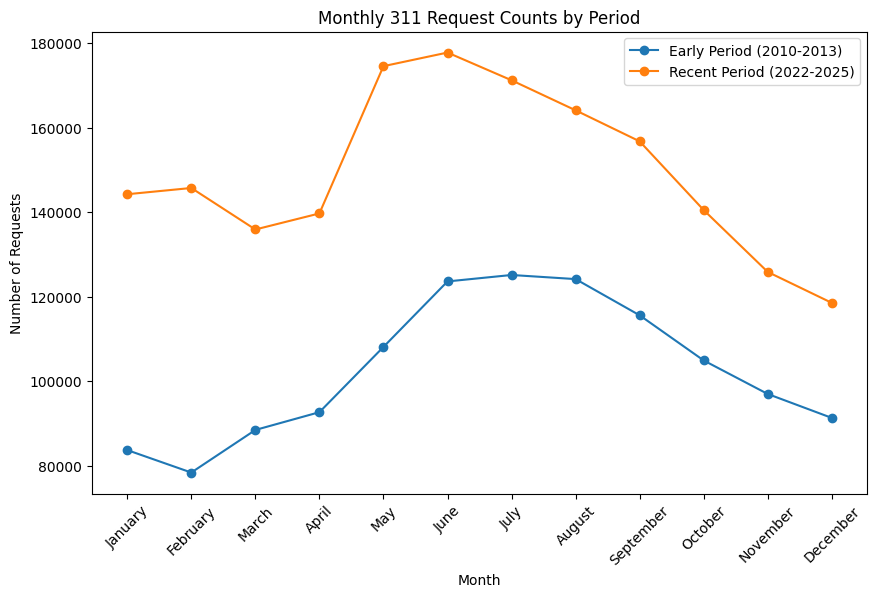

In [ ]:
# Plot monthly request counts by period

plt.figure(figsize=(10, 6))

for period in month_by_period["Period"].unique():
    data = month_by_period[month_by_period["Period"] == period]
    plt.plot(data["Month Name"], data["Count"], marker="o", label=period) # "o" - adds a cricle marker ti each data point on the line chart

plt.title("Monthly 311 Request Counts by Period")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45) #labels displayed at 45 degree angle
plt.legend()
plt.show()

##### The monthly line chart shows that the recent period has higher request counts than the early period in every month. This is expected because the recent period has more records overall. More importantly, both periods show a similar seasonal shape. Request counts increase in the spring, stay high during the summer months, and then decline into the fall and winter.

##### In the early period, the highest monthly count appears in July. In the recent period, the highest monthly count appears in June. The recent period also has higher January and February counts compared with the early period, which helps explain why the Winter share increased in the season-by-period table. Overall, this chart supports RQ2 by showing that reported 311 request activity follows monthly and seasonal patterns.

In [ ]:
division_pivot = division_by_period.pivot(
    index="Division",
    columns="Period",
    values="Percent of Period"
).fillna(0)

division_pivot

Period,Early Period (2010-2013),Recent Period (2022-2025)
Division,,
311,2.46,1.67
City of Toronto,0.01,0.00
"Environment, Climate & Forestry",0.00,2.02
Municipal Licensing & Standards,13.12,24.54
Parks and Recreation,0.00,0.08
"Parks, Forestry & Recreation",0.00,5.47
Solid Waste Management Services,44.64,33.93
"Solid Waste Management Services,Transfer",0.00,0.00
Toronto Water,15.76,7.70


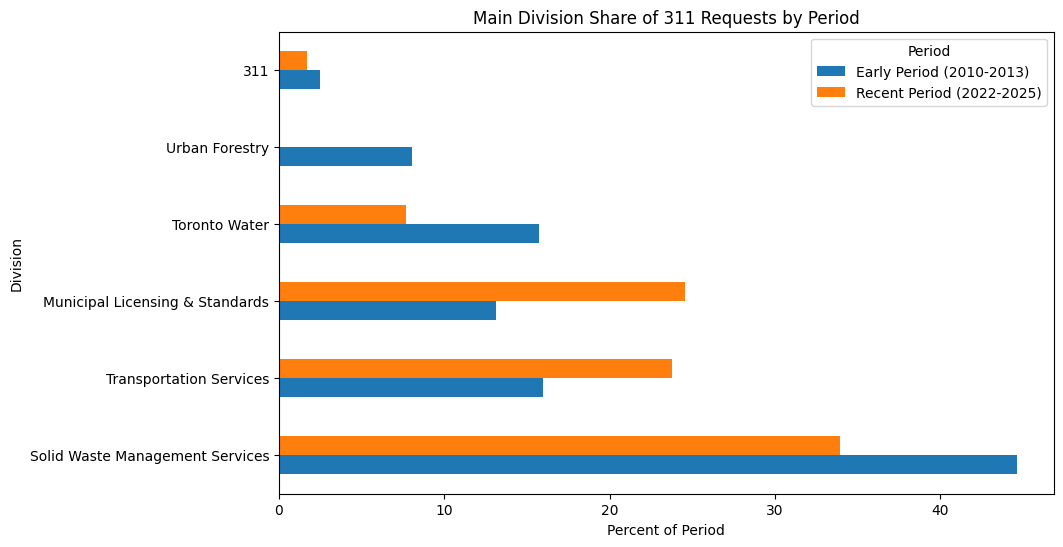

In [ ]:
#Plot main division percentage by period

main_divisions = [
    "Solid Waste Management Services",
    "Transportation Services",
    "Municipal Licensing & Standards",
    "Toronto Water",
    "Urban Forestry",
    "311"
]

division_pivot_main = division_pivot.loc[main_divisions]
division_pivot_main.plot(kind="barh", figsize=(10, 6))
plt.title("Main Division Share of 311 Requests by Period")
plt.xlabel("Percent of Period")
plt.ylabel("Division")
plt.legend(title="Period")
plt.show()

##### This chart focuses on the main divisions with the largest shares of reported 311 requests. Solid Waste Management Services remains the largest division in both periods, but its share decreased from 44.64% in the early period to 33.93% in the recent period. Municipal Licensing & Standards increased from 13.12% to 24.54%, and Transportation Services increased from 15.98% to 23.79%. Toronto Water decreased from 15.76% to 7.70%.

##### This supports RQ1 because it shows that reported 311 demand by City division changed between the early and recent periods. I focused the chart on the main divisions because the smaller categories had very low percentages and made the full chart harder to read. The full division table is still included above for transparency.

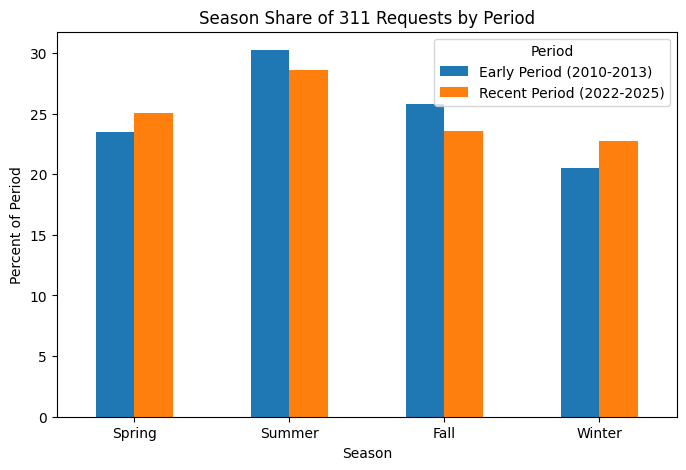

In [ ]:
#Plot season percentage by period

season_pivot = season_by_period.pivot(
    index="Season",
    columns="Period",
    values="Percent of Period"
)

season_pivot = season_pivot.reindex(["Spring", "Summer", "Fall", "Winter"])
season_pivot.plot(kind="bar", figsize=(8, 5))
plt.title("Season Share of 311 Requests by Period")
plt.xlabel("Season")
plt.ylabel("Percent of Period")
plt.xticks(rotation=0)
plt.legend(title="Period")
plt.show()

#####The season share chart shows that reported 311 requests are spread across all four seasons in both periods. Summer has the highest share in both the early and recent periods, but the seasonal pattern is not extremely uneven. In the early period, Summer made up 30.24% of requests, while in the recent period it made up 27.64%.

#####Winter increased from 20.55% in the early period to 23.80% in the recent period. Spring also increased slightly, while Fall decreased slightly. This supports RQ2 because it shows that there are seasonal differences in reported 311 request patterns, but the overall seasonal distribution is still fairly balanced.

### Pareto / Cumulative Share Analysis for Service Request Type

This analysis checks how concentrated reported 311 demand is across service request types. Since there are 970 unique service request types, a Pareto-style chart helps show whether a small number of categories account for most requests or whether demand is spread across many categories.

In [ ]:
# I really want to know the answer to this, Are most 311 requests coming from only a few service request types, or are requests spread across many different types?
# I'm using the Pareto analysis, "80/20 rule" to find out

service_counts = df["Service Request Type"].value_counts().reset_index()
service_counts.columns = ["Service Request Type", "Count"]
service_counts["Percent"] = (service_counts["Count"] / service_counts["Count"].sum() * 100).round(2)
service_counts["Cumulative Percent"] = service_counts["Percent"].cumsum().round(2) #cumulative sum
service_counts.head(20)

,Service Request Type,Count,Percent,Cumulative Percent
0,Property Standards,94487,3.12,3.12
1,Residential Furniture / Not Picked Up,83812,2.77,5.89
2,General Pruning,81628,2.70,8.59
3,Sewer Service Line-Blocked,71653,2.37,10.96
4,Res / Garbage / Not Picked Up,66825,2.21,13.17
5,Injured - Wildlife,64628,2.13,15.30
6,Residential: Bin: Repair or Replace Lid,62759,2.07,17.37
7,Res / Recycle / Not Picked Up,57951,1.91,19.28
8,Res / Organic Green Bin / Not Picked Up,57450,1.90,21.18
9,Storm Clean Up,57201,1.89,23.07


##### Pareto / Cumulative Share Result
The Pareto-style table shows that the top 20 Service Request Type categories account for 34.38% of all records. Property Standards is the largest category, but it only represents 3.24% of the full dataset. This means reported 311 demand is not dominated by one single service request type.

This result supports RQ1 because it shows that reported demand is spread across many service request categories. The dataset has 970 unique service request types, so the top categories are important for identifying high-volume requests, but they do not explain the full dataset on their own. This supports the use of rankings, percentage shares, and cumulative shares rather than relying only on raw counts. This is a good sign, the data is not being skewed by one category alone.

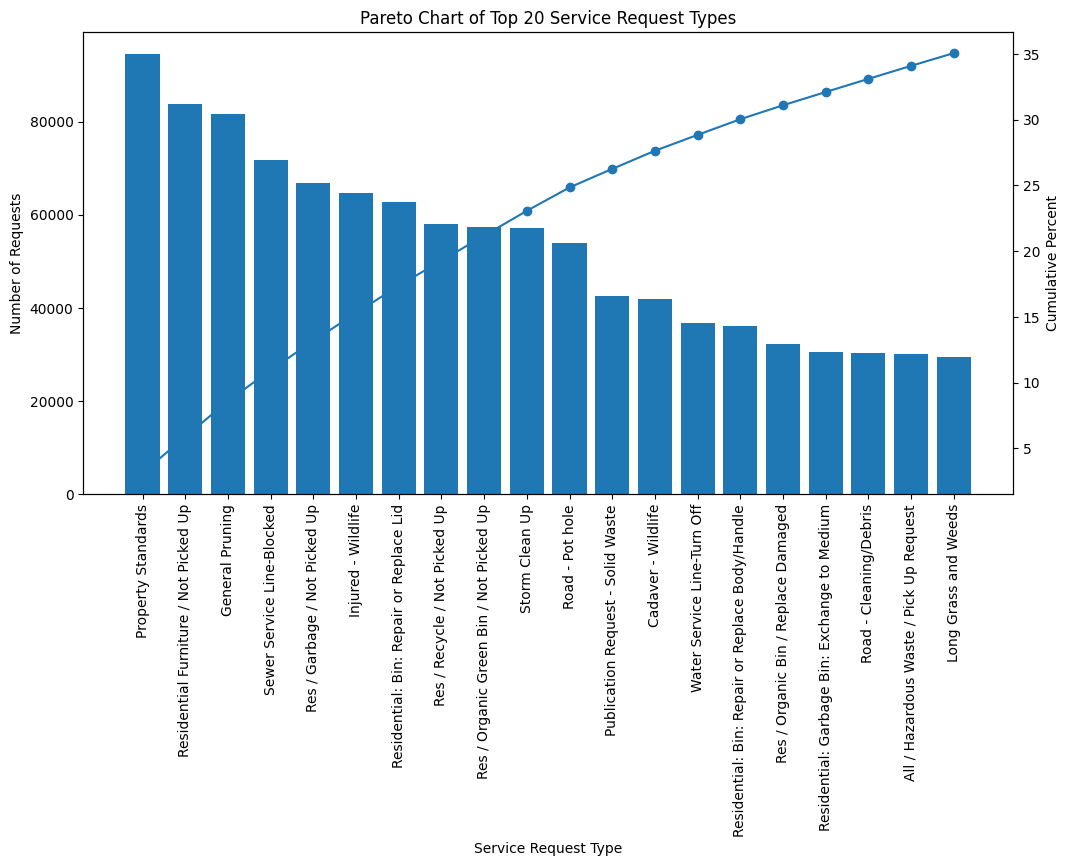

In [ ]:
# Plot Pareto-style chart for top 20 service request types

top20_pareto = service_counts.head(20)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(top20_pareto["Service Request Type"], top20_pareto["Count"])
ax1.set_xlabel("Service Request Type")
ax1.set_ylabel("Number of Requests")
ax1.tick_params(axis="x", rotation=90)
ax2 = ax1.twinx()
ax2.plot(top20_pareto["Service Request Type"], top20_pareto["Cumulative Percent"], marker="o")
ax2.set_ylabel("Cumulative Percent")
plt.title("Pareto Chart of Top 20 Service Request Types")
plt.show()

##### The Pareto chart shows the top 20 Service Request Type categories by request count and their cumulative share of the full dataset. Property Standards has the highest count, but the cumulative line shows that the top 20 categories together only account for about 34.38% of all records. This means reported 311 demand is spread across many service request categories rather than being concentrated in only a few. This supports RQ1 because it shows why both rankings and percentage shares are needed when comparing early and recent demand patterns. It also supports the decision to focus on high-volume categories for interpretation while recognizing that the dataset contains a much wider range of request types.

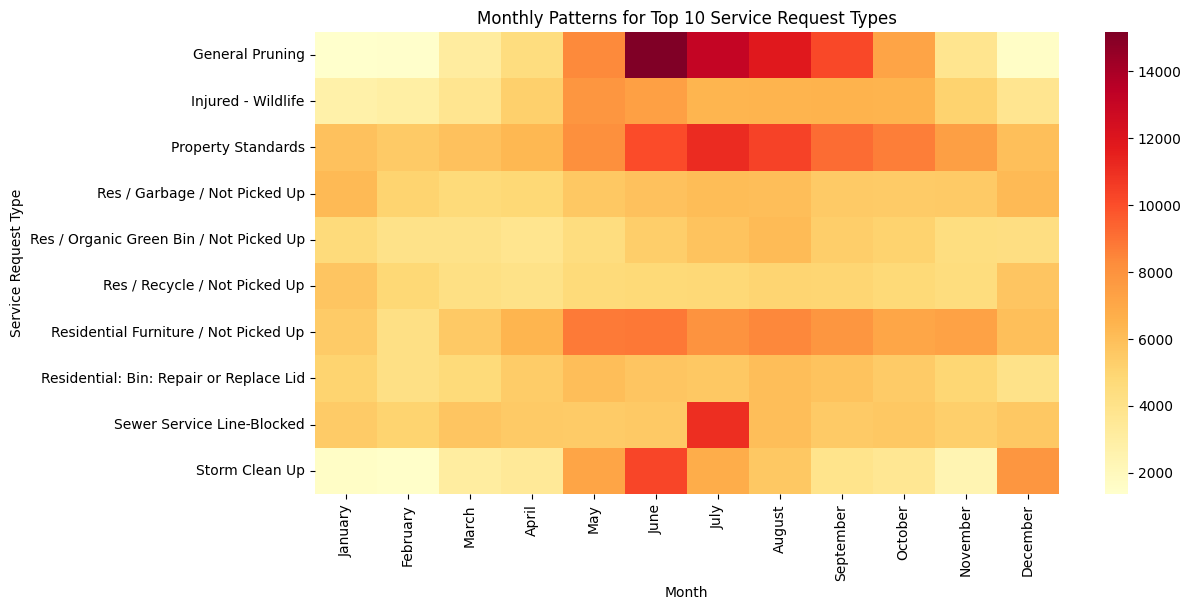

In [ ]:
#Heatmap for top 10 service request types over both periods

top10_service_types = df["Service Request Type"].value_counts().head(10).index

heatmap_data = (
    df[df["Service Request Type"].isin(top10_service_types)]
    .groupby(["Service Request Type", "Month Name"])
    .size()
    .reset_index(name="Count")
)

heatmap_pivot = heatmap_data.pivot(
    index="Service Request Type",
    columns="Month Name",
    values="Count"
).fillna(0)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

heatmap_pivot = heatmap_pivot[month_order]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_pivot, annot=False, cmap="YlOrRd") # i want it to be pink
plt.title("Monthly Patterns for Top 10 Service Request Types")
plt.xlabel("Month")
plt.ylabel("Service Request Type")
plt.show()

### Heatmap

##### The heatmap shows monthly patterns for the top 10 Service Request Type categories. Darker colours represent months with higher request counts. The chart shows that high-volume request types do not all follow the same monthly pattern.

##### Property Standards and Residential Furniture / Not Picked Up show higher activity in the warmer months. Road - Pot hole has a clear increase around March and April, which may reflect road conditions after winter. Injured - Wildlife is also higher in the warmer months, especially from May to October. Publication Request - Solid Waste has a noticeable spike in January and another high point around September.

##### This supports RQ2 because it shows that monthly and seasonal patterns vary by service request type. The overall monthly trend is useful, but this heatmap shows that different categories have their own timing patterns. These results should still be interpreted as reported 311 activity, not as proof of actual service conditions.

## Monthly Request Counts

I build the monthly count table here rather than later, because both the seasonal tests in the next
section and the forecasting models further down are based on it.

In [ ]:
# Create monthly request counts by year and month

monthly_counts = (
    df.groupby(["Year", "Month", "Month Name"])
    .size()
    .reset_index(name="Actual Count")
    .sort_values(["Year", "Month"])
)

monthly_counts

,Year,Month,Month Name,Actual Count
0,2010,1,January,15177
1,2010,2,February,13918
2,2010,3,March,19274
3,2010,4,April,20092
4,2010,5,May,20336
5,2010,6,June,29534
6,2010,7,July,26681
7,2010,8,August,26711
8,2010,9,September,23540
9,2010,10,October,21342


## Statistical Testing of the Milestone 3 Findings

In Milestone 3 I compared percentages by eye. For example, Solid Waste Management Services went from
44.64% of the early period to 33.93% of the recent period. I described that as a change, but I never
tested whether it was a statistically significant one.

CMTH642 Modules 3, 4, and 5 each end with a road map for choosing a test: how many groups am I comparing,
are they paired or unpaired, and are they normally distributed. I am following that road map here, so I
check normality first and let the result decide which tests I use.

In [ ]:
# Importing the tests I need
# I am checking normality first because that decides whether I use parametric or non-parametric tests

from scipy.stats import shapiro, chi2_contingency, wilcoxon

print("Statistical test libraries imported successfully.")

Statistical test libraries imported successfully.


In [ ]:
# Step 1: Are my monthly request counts normally distributed?
# Shapiro-Wilk null hypothesis: the data IS normally distributed.
# So a p-value below 0.05 means I reject normality and go down the non-parametric branch.

early_monthly = monthly_counts[monthly_counts["Year"].isin([2010, 2011, 2012, 2013])]
recent_monthly = monthly_counts[monthly_counts["Year"].isin([2022, 2023, 2024, 2025])]

shapiro_early = shapiro(early_monthly["Actual Count"])
shapiro_recent = shapiro(recent_monthly["Actual Count"])

print("Early period  (n =", len(early_monthly), ") statistic:", round(shapiro_early.statistic, 4),
      "p-value:", round(shapiro_early.pvalue, 4))
print("Recent period (n =", len(recent_monthly), ") statistic:", round(shapiro_recent.statistic, 4),
      "p-value:", round(shapiro_recent.pvalue, 4))

Early period  (n = 48 ) statistic: 0.9748 p-value: 0.3847
Recent period (n = 48 ) statistic: 0.9897 p-value: 0.9455


##### Shapiro-Wilk did not reject normality for either period (early p = 0.3847, recent p = 0.9455). With only 12 paired months I still used the Wilcoxon signed-rank test as the safer choice, and ran the paired t-test as a robustness check. Both agree.

In [ ]:
# Step 2: Did the division mix actually change between the two periods?
# Chi-square test of independence, from CMTH642 Module 2.
# Null hypothesis: Period and Division are independent (the mix did NOT change).

division_table = pd.crosstab(df["Period"], df["Division"])

chi2_stat, chi2_p, chi2_dof, chi2_expected = chi2_contingency(division_table)

print("Chi-square statistic:", round(chi2_stat, 2))
print("Degrees of freedom:", chi2_dof)
print("p-value:", chi2_p)
division_table

Chi-square statistic: 384422.38
Degrees of freedom: 11
p-value: 0.0


Division,311,City of Toronto,"Environment, Climate & Forestry",Municipal Licensing & Standards,Parks and Recreation,"Parks, Forestry & Recreation",Solid Waste Management Services,"Solid Waste Management Services,Transfer",Toronto Water,Transportation Services,Unknown,Urban Forestry
Period,,,,,,,,,,,,
Early Period (2010-2013),30282,85,0,161732,0,0,550241,0,194328,197045,0,99007
Recent Period (2022-2025),29937,0,36174,440451,1437,98077,608840,45,138202,426837,14544,0


In [ ]:
# Cramer's V, because with 2.9 million rows the p-value will be tiny no matter what.
# Cramer's V measures HOW BIG the difference is, on a 0 to 1 scale, not just whether it exists.

n_total = division_table.values.sum()
min_dimension = min(division_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n_total * min_dimension))

print("Total observations:", n_total)
print("Cramer's V:", round(cramers_v, 4))
print()
print("Rough guide: 0.1 = small, 0.3 = medium, 0.5 = large")

Total observations: 3027264
Cramer's V: 0.3564

Rough guide: 0.1 = small, 0.3 = medium, 0.5 = large


##### The chi-square test gave p < 0.001, but with 3,027,264 records almost anything comes out significant. Cramér's V was 0.3564, a medium effect, so the division mix shifted by a real moderate amount. This supports RQ1 with a tested result rather than only a percentage comparison.

In [ ]:
# Step 3: Did monthly request volume change between the periods?
# This is a PAIRED comparison: each of the 12 calendar months appears in both periods.
# Wilcoxon signed-rank test, from CMTH642 Module 4, is the paired non-parametric test.

early_by_month = early_monthly.groupby("Month")["Actual Count"].mean()
recent_by_month = recent_monthly.groupby("Month")["Actual Count"].mean()

paired_counts = pd.DataFrame({
    "Early Average": early_by_month.round(0),
    "Recent Average": recent_by_month.round(0)
})
paired_counts["Difference"] = paired_counts["Recent Average"] - paired_counts["Early Average"]

volume_test = wilcoxon(paired_counts["Early Average"], paired_counts["Recent Average"])
print("Wilcoxon signed-rank on monthly VOLUME")
print("statistic:", volume_test.statistic, "p-value:", round(volume_test.pvalue, 5))
paired_counts

Wilcoxon signed-rank on monthly VOLUME
statistic: 0.0 p-value: 0.00049


,Early Average,Recent Average,Difference
Month,,,
1,20918.0,36055.0,15137.0
2,19590.0,36424.0,16834.0
3,22109.0,33969.0,11860.0
4,23161.0,34918.0,11757.0
5,27020.0,43631.0,16611.0
6,30896.0,44436.0,13540.0
7,31277.0,42796.0,11519.0
8,31035.0,41019.0,9984.0
9,28892.0,39184.0,10292.0


In [ ]:
# Step 4: This is the more interesting question.
# The test above only proves the recent period has more requests, which I already knew.
# What RQ2 actually asks is whether the SHAPE of the year changed.
# So I convert each month to a share of its own period total, then run the same paired test.

early_share = (early_by_month / early_by_month.sum() * 100).round(2)
recent_share = (recent_by_month / recent_by_month.sum() * 100).round(2)

paired_shares = pd.DataFrame({
    "Early Percent": early_share,
    "Recent Percent": recent_share
})
paired_shares["Difference"] = (paired_shares["Recent Percent"] - paired_shares["Early Percent"]).round(2)

shape_test = wilcoxon(paired_shares["Early Percent"], paired_shares["Recent Percent"])
print("Wilcoxon signed-rank on monthly SHARE (seasonal shape)")
print("statistic:", shape_test.statistic, "p-value:", round(shape_test.pvalue, 5))
paired_shares

Wilcoxon signed-rank on monthly SHARE (seasonal shape)
statistic: 38.0 p-value: 0.96973


,Early Percent,Recent Percent,Difference
Month,,,
1,6.79,8.04,1.25
2,6.36,8.12,1.76
3,7.17,7.57,0.40
4,7.52,7.78,0.26
5,8.77,9.73,0.96
6,10.03,9.90,-0.13
7,10.15,9.54,-0.61
8,10.07,9.14,-0.93
9,9.38,8.73,-0.65


##### The volume test gave p = 0.00049 and the shape test gave p = 0.96973. The shape test is structurally limited though, because the 12 shares add to 100% in each period so the differences must sum to zero. The chi-square goodness of fit test below is the correct test for that question.

#RESEARCH QUESTION 3

## Comparability Audit

RQ3 asks which differences between the early and recent periods can be compared responsibly, and which
need caution. In Milestone 3 I described this as a plan but did not build it. This section builds it.

The method is straightforward. For each field, I list the unique values that appear in the early period
and the unique values that appear in the recent period, then check how much the two lists overlap. A field
where almost all values appear in both periods can be compared directly. A field where the value lists
barely overlap cannot, because a difference in counts might just mean the City renamed or restructured
the categories.

In [ ]:
# For each field, compare the set of values used in the early period against the recent period

def compare_field(data, column):
    """Returns overlap statistics for one column, comparing early period values to recent period values."""
    early_values = set(data.loc[data["Period"].str.contains("Early"), column].dropna().unique())
    recent_values = set(data.loc[data["Period"].str.contains("Recent"), column].dropna().unique())

    shared = early_values & recent_values
    all_values = early_values | recent_values

    # Guarding against a divide by zero in case a column is empty in one period
    if len(all_values) == 0:
        percent_shared = 0.0
    else:
        percent_shared = round(len(shared) / len(all_values) * 100, 2)

    return {
        "Field": column,
        "Unique (Early)": len(early_values),
        "Unique (Recent)": len(recent_values),
        "Shared Values": len(shared),
        "Early Only": len(early_values - recent_values),
        "Recent Only": len(recent_values - early_values),
        "Percent Shared": percent_shared
    }


audit_fields = ["Status", "Division", "Section", "Service Request Type", "Ward"]
comparability_table = pd.DataFrame([compare_field(df, field) for field in audit_fields])
comparability_table

,Field,Unique (Early),Unique (Recent),Shared Values,Early Only,Recent Only,Percent Shared
0,Status,6,6,3,3,3,33.33
1,Division,7,10,5,2,5,41.67
2,Section,15,25,12,3,13,42.86
3,Service Request Type,471,867,348,123,519,35.15
4,Ward,45,26,2,43,24,2.90


In [ ]:
# Turning the overlap percentage into a plain-language verdict
# I am using the same if/elif style I used for the season function earlier in the notebook

def comparability_verdict(percent_shared):
    if percent_shared >= 80:
        return "Safe to compare"
    elif percent_shared >= 50:
        return "Compare with caution"
    else:
        return "Not comparable"


comparability_table["Verdict"] = comparability_table["Percent Shared"].apply(comparability_verdict)
comparability_table = comparability_table.sort_values("Percent Shared", ascending=False)
comparability_table

,Field,Unique (Early),Unique (Recent),Shared Values,Early Only,Recent Only,Percent Shared,Verdict
2,Section,15,25,12,3,13,42.86,Not comparable
1,Division,7,10,5,2,5,41.67,Not comparable
3,Service Request Type,471,867,348,123,519,35.15,Not comparable
0,Status,6,6,3,3,3,33.33,Not comparable
4,Ward,45,26,2,43,24,2.90,Not comparable


In [ ]:
# Ward is the field I flagged in Milestone 3, so I want to look at it directly

early_wards = set(df.loc[df["Period"].str.contains("Early"), "Ward"].dropna().unique())
recent_wards = set(df.loc[df["Period"].str.contains("Recent"), "Ward"].dropna().unique())

print("Ward values in the early period:", len(early_wards))
print("Ward values in the recent period:", len(recent_wards))
print("Ward values in both:", len(early_wards & recent_wards))
print()
print("Examples of early-only ward values:", sorted(list(early_wards - recent_wards))[:5])
print("Examples of recent-only ward values:", sorted(list(recent_wards - early_wards))[:5])

Ward values in the early period: 45
Ward values in the recent period: 26
Ward values in both: 2

Examples of early-only ward values: ['Beaches-East York (31)', 'Beaches-East York (32)', 'Davenport (17)', 'Davenport (18)', 'Don Valley East (33)']
Examples of recent-only ward values: ['Beaches-East York (19)', 'Davenport (09)', 'Don Valley East (16)', 'Don Valley North (17)', 'Don Valley West (15)']


In [ ]:
# Plotting both measures together, because the difference between them is the point.
# Label overlap counts category NAMES. Record coverage counts how many actual RECORDS
# sit in categories that exist in both periods. Division looks bad on one and fine on the other.

plot_data = coverage_table.sort_values("Min Coverage %")

y = np.arange(len(plot_data))
height = 0.38

plt.figure(figsize=(10, 6))
plt.barh(y + height/2, plot_data["Label Overlap %"], height, label="Label overlap (category names)")
plt.barh(y - height/2, plot_data["Min Coverage %"], height, label="Record coverage (actual records)")

plt.axvline(90, linestyle="--", color="grey", label="Safe to compare (90% coverage)")
plt.axvline(70, linestyle=":", color="grey", label="Compare with caution (70%)")

plt.yticks(y, plot_data["Field"])
plt.xlim(0, 100)
plt.xlabel("Percent")
plt.ylabel("Field")
plt.title("RQ3: Label Overlap vs Record Coverage by Field")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

NameError: name 'coverage_table' is not defined

##### This graph answers RQ3. Division has the highest record coverage at 91.63% so division comparisons are reliable. Ward is lowest at 1.49% because of the ward restructuring, so no ward comparisons were made. Service Request Type sits in the middle at 62.32%, meaning a category appearing only in the recent period may be a renamed old one rather than new demand.

## Baseline Model

This section builds one simple baseline model connected to RQ2. The goal is to test whether past monthly request patterns can provide a basic prediction of recent monthly request volume. The model uses 2022–2024 monthly request counts as training data and predicts 2025 monthly request counts. This avoids leakage because the 2025 test data is not used to create the baseline predictions.

In [ ]:
# Create training data using 2022 to 2024

train_monthly = monthly_counts[monthly_counts["Year"].isin([2022, 2023, 2024])]
train_monthly

In [ ]:
# Create baseline predictions by averaging each month from 2022 to 2024
baseline_predictions = (
    train_monthly
    .groupby(["Month", "Month Name"])["Actual Count"]
    .mean()
    .reset_index(name="Predicted Count")
)

baseline_predictions["Predicted Count"] = baseline_predictions["Predicted Count"].round(0)
baseline_predictions

In [ ]:
#Test data using 2025 counts
test_2025 = monthly_counts[monthly_counts["Year"] == 2025].copy()
test_2025

In [ ]:
# Compare actual 2025 counts with baseline predictions
baseline_results = pd.merge(
    test_2025,
    baseline_predictions,
    on=["Month", "Month Name"]
)

baseline_results

In [ ]:
# Calculate prediction errors

baseline_results["Error"] = baseline_results["Actual Count"] - baseline_results["Predicted Count"]
baseline_results["Absolute Error"] = baseline_results["Error"].abs()
baseline_results["Percent Error"] = (
    baseline_results["Absolute Error"] / baseline_results["Actual Count"] * 100
).round(2)
baseline_results

#####The baseline model compares actual 2025 monthly request counts against predictions created from the average monthly counts in 2022, 2023, and 2024. The model performs better in some months, such as May, June, August, October, and November, where the percent error is relatively low. However, the model performs worse in February and December, where the actual 2025 counts are much higher than the baseline prediction.

##### This shows that a simple monthly average can capture some of the regular monthly pattern, but it does not fully account for unusual spikes or changes in reporting volume. This connects to RQ2 because the model is based on monthly request patterns and shows where those patterns are more or less stable.

In [ ]:
# Calculate baseline model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    baseline_results["Actual Count"],
    baseline_results["Predicted Count"]
)
rmse = np.sqrt(
    mean_squared_error(
        baseline_results["Actual Count"],
        baseline_results["Predicted Count"]
    )
)
mape = baseline_results["Percent Error"].mean()
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("Mean Absolute Percentage Error (MAPE):", round(mape, 2), "%")

##### The baseline model was evaluated by comparing the predicted 2025 monthly request counts with the actual 2025 monthly request counts. The Mean Absolute Error (MAE) was 5,578.75, meaning the model was off by about 5,579 requests per month on average. The Root Mean Squared Error (RMSE) was 8,201.21, which is higher than the MAE because some months had larger errors. This matches the month-by-month error table, where February and December had the largest prediction errors.

##### The Mean Absolute Percentage Error (MAPE) was 13.39%, meaning the baseline predictions were off by about 13.39% on average. For a simple monthly average baseline, this gives a useful starting point. The model captures some regular monthly patterns, but it does not fully explain unusual spikes or changes in reporting volume. This supports RQ2 because it shows that monthly request patterns are somewhat predictable, but still uncertain.

In [ ]:
# Plot actual vs predicted monthly request counts for 2025

plt.figure(figsize=(10, 6))
plt.plot(
    baseline_results["Month Name"],
    baseline_results["Actual Count"],
    marker="o",
    label="Actual 2025 Count"
)

plt.plot(
    baseline_results["Month Name"],
    baseline_results["Predicted Count"],
    marker="o",
    label="Predicted Count"
)

plt.title("Baseline Model: Actual vs Predicted Monthly Requests for 2025")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### The actual versus predicted chart shows how the baseline model performed across each month of 2025. The predicted line follows the general monthly pattern in some parts of the year, especially from May to November, where the gap between the actual and predicted values is smaller.
##### However, the model misses larger spikes in February and December. February 2025 had the largest difference between actual and predicted values, which increased the overall RMSE. This shows that the baseline model can provide a basic monthly expectation, but it does not fully capture unusual changes or spikes in reported 311 activity.
##### Overall, the baseline model is useful as a simple comparison point, but it should not be treated as a final predictive model. The results show that monthly patterns are somewhat stable, but there is still uncertainty in future request volume.

## Model Comparison

In Milestone 3 I only had one forecasting model. My supervisor's feedback asked me to name that model
properly, compare it against a real seasonal-naive benchmark, add WAPE, use rolling-origin backtesting
across more than one year, and model divisions instead of only total monthly volume.

In [ ]:
# Step 5: Setting up the modelling data.
# I only use the recent period because there is an 8 year gap between 2013 and 2022,
# and a year trend fitted across that gap would not mean anything.

import statsmodels.api as sm
import statsmodels.formula.api as smf

model_data = monthly_counts[monthly_counts["Year"].isin([2022, 2023, 2024, 2025])].copy()

# renaming the column because a formula cannot handle a name with a space in it
model_data["Count"] = model_data["Actual Count"]
model_data = model_data.sort_values(["Year", "Month"]).reset_index(drop=True)

print("Modelling data shape:", model_data.shape)

model_data.head()

In [ ]:
# Step 6: My error metrics.
# I added WAPE because my supervisor asked for it.
# MAPE gives every month the same weight no matter how busy it was, so a small error in a quiet
# month can look as bad as a big error in a busy one. WAPE divides total absolute error by total
# actual volume, which is fairer when the months are different sizes.

def evaluate_forecast(actual, predicted):
    """Returns MAE, RMSE, MAPE and WAPE for one set of predictions."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    wape = np.sum(np.abs(actual - predicted)) / np.sum(actual) * 100

    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE": round(mape, 2),
        "WAPE": round(wape, 2)
    }


print("Metric function defined.")

In [ ]:
# Step 7: My four models.
# The first two look similar but they are not the same model, which is the point my supervisor
# was making. The historical average uses ALL training years. The seasonal-naive benchmark uses
# only the year right before the test year.
# Model 3 is the multiple linear regression from CMTH642 Module 6 and CIND123 Module 10.
# Model 4 is the generalized linear model idea from CMTH642 Module 8, using the Poisson family
# because monthly request counts are counts of events in a fixed period (CIND123 Module 6).

def hist_average_predict(train, test):
    """Milestone 3 baseline: the average of that calendar month across ALL training years."""
    month_means = train.groupby("Month")["Count"].mean()
    return test["Month"].map(month_means).values.astype(float)


def seasonal_naive_predict(train, test):
    """Standard benchmark: the value of that same month in the LAST training year only."""
    last_year = train["Year"].max()
    last_year_values = train[train["Year"] == last_year].set_index("Month")["Count"]
    return test["Month"].map(last_year_values).values.astype(float)


def ols_predict(train, test):
    """Linear regression on a year trend plus month indicators.
    C(Month) tells the formula to treat Month as a category and not as a number.
    Without C() the model would assume December is 12 times January."""
    fitted = smf.ols("Count ~ C(Month) + Year", data=train).fit()
    return fitted.predict(test).values


def poisson_predict(train, test):
    """The same formula fitted as a generalized linear model with a log link."""
    fitted = smf.glm("Count ~ C(Month) + Year", data=train,
                     family=sm.families.Poisson()).fit()
    return fitted.predict(test).values


models = {
    "Seasonal historical-average (baseline)": hist_average_predict,
    "Seasonal-naive benchmark": seasonal_naive_predict,
    "OLS trend + season": ols_predict,
    "Poisson GLM": poisson_predict
}

print("Four models defined.")

In [ ]:
# Step 8: Rolling-origin backtest.
# For each origin the model trains only on the months BEFORE the test year and then forecasts
# all 12 months of that year. Normal k-fold cross validation is not right for time data because
# shuffling the rows would let the model train on future months to predict past ones.
# The two regression models need 13 parameters (an intercept, 11 month indicators and a year term),
# so at the 2023 origin there are not enough training rows and I leave them out.

backtest_rows = []

for test_year in [2023, 2024, 2025]:
    train = model_data[model_data["Year"] < test_year]
    test = model_data[model_data["Year"] == test_year]

    print("Test year:", test_year,
          "| training years:", sorted(train["Year"].unique()),
          "| training rows:", len(train),
          "| test rows:", len(test))

    for model_name, model_function in models.items():
        needs_thirteen = model_name.startswith("OLS") or model_name.startswith("Poisson")

        if needs_thirteen and len(train) < 14:
            continue

        predicted = model_function(train, test)
        result = evaluate_forecast(test["Count"].values, predicted)
        result["Model"] = model_name
        result["Test Year"] = test_year
        result["Train n"] = len(train)
        backtest_rows.append(result)

backtest = pd.DataFrame(backtest_rows)[
    ["Model", "Test Year", "Train n", "MAE", "RMSE", "MAPE", "WAPE"]
]

backtest

In [ ]:
# Step 9: Stability across the origins.
# I only compare 2024 and 2025 here because those are the two origins where all four models
# could be fitted. A low average error with a high standard deviation is a warning sign,
# because it means the model only did well on one particular year.

stability = (
    backtest[backtest["Test Year"] >= 2024]
    .groupby("Model")[["MAE", "RMSE", "MAPE", "WAPE"]]
    .agg(["mean", "std"])
    .round(2)
)

stability

In [ ]:
# Plotting the stability so it is easier to see

plt.figure(figsize=(9, 5))

for model_name in backtest["Model"].unique():
    subset = backtest[backtest["Model"] == model_name]
    plt.plot(subset["Test Year"], subset["MAPE"], marker="o", label=model_name)

plt.title("Model Stability Across Rolling Origins")
plt.xlabel("Test Year")
plt.ylabel("MAPE (%)")
plt.xticks([2023, 2024, 2025])
plt.legend()
plt.show()

### Forecasting by division

My supervisor pointed out that forecasting only total monthly volume does not line up with RQ2,
because RQ2 asks about high-volume categories. So I repeated the comparison division by division.

Forestry needs to be handled carefully. The same work appears under three different division names
across the study period, so I have to combine those labels into one series before I can model it.

In [ ]:
# Step 10: Forecasting each of the main divisions on its own.
# The forestry work appears under three different division names, so I group them together first.

forestry_labels = [
    "Parks, Forestry & Recreation",
    "Environment, Climate & Forestry",
    "Parks and Recreation"
]

division_groups = {
    "Solid Waste Management Services": df[df["Division"] == "Solid Waste Management Services"],
    "Municipal Licensing & Standards": df[df["Division"] == "Municipal Licensing & Standards"],
    "Transportation Services": df[df["Division"] == "Transportation Services"],
    "Toronto Water": df[df["Division"] == "Toronto Water"],
    "Forestry (all three labels combined)": df[df["Division"].isin(forestry_labels)]
}


def build_monthly(subset):
    """Turns a filtered dataframe into a monthly count table for 2022 onwards."""
    monthly = subset.groupby(["Year", "Month"]).size().reset_index(name="Count")
    monthly = monthly[monthly["Year"] >= 2022]
    return monthly.sort_values(["Year", "Month"]).reset_index(drop=True)


division_rows = []

for division_name, subset in division_groups.items():
    monthly = build_monthly(subset)

    if len(monthly) < 48:
        print("Skipping", division_name, "- only", len(monthly), "monthly observations")
        continue

    train = monthly[monthly["Year"] < 2025]
    test = monthly[monthly["Year"] == 2025]

    for model_name, model_function in models.items():
        predicted = model_function(train, test)
        result = evaluate_forecast(test["Count"].values, predicted)
        result["Division"] = division_name
        result["Model"] = model_name
        division_rows.append(result)

division_results = pd.DataFrame(division_rows)[
    ["Division", "Model", "MAE", "RMSE", "MAPE", "WAPE"]
]

division_results

In [ ]:
# Step 11: Which model works best for each division, using WAPE

best_per_division = division_results.loc[
    division_results.groupby("Division")["WAPE"].idxmin()
][["Division", "Model", "WAPE", "MAPE"]].sort_values("WAPE")

best_per_division

In [ ]:
# Step 12: Showing what happens if I forecast the forestry division using only its recent label.
# This is the RQ3 comparability problem actually breaking a modelling step, not just a caution.

forestry_one_label = build_monthly(df[df["Division"] == "Parks, Forestry & Recreation"])

print("Months available for 'Parks, Forestry & Recreation':", len(forestry_one_label))
print("Years present:", sorted(forestry_one_label["Year"].unique()))
print("Rows available for a 2025 test set:",
      len(forestry_one_label[forestry_one_label["Year"] == 2025]))
print()
print("The 2025 test set is empty because the division was renamed to")
print("Environment, Climate & Forestry in 2025, so this division cannot be")
print("forecast at all unless the three labels are combined first.")
forestry_one_label

### Forecasting 2026 and 2027

My supervisor asked me to extend the forecast past the evaluation period. These models are trained on
all of 2022 to 2025 and forecast forward.

This is a forecast and not an evaluation. I have not used any 2026 or 2027 actual values, and I cannot
measure the accuracy until those years are finished and published.

In [ ]:
# Step 13: True future forecast.
# I train on everything I have and predict forward. I am NOT using any 2026 or 2027 actual values.

future = pd.DataFrame(
    [(year, month) for year in [2026, 2027] for month in range(1, 13)],
    columns=["Year", "Month"]
)

future["Seasonal historical-average"] = hist_average_predict(model_data, future).round(0)
future["Seasonal-naive"] = seasonal_naive_predict(model_data, future).round(0)
future["OLS trend + season"] = ols_predict(model_data, future).round(0)
future

In [ ]:
# Step 14: The yearly totals each forecast implies, compared against the actual years I have

future_totals = future.groupby("Year")[
    ["Seasonal historical-average", "Seasonal-naive", "OLS trend + season"]
].sum()

print("Forecast annual totals:")
print(future_totals)
print()
print("Actual annual totals for comparison:")
print(model_data.groupby("Year")["Count"].sum())

In [ ]:
# Step 15: Compute cost.
# My supervisor's checklist asks me to evaluate time or compute cost as well as accuracy.
# I am using the same timing and memory approach I used in my CIND 830 assignment.

import time
import tracemalloc

cost_train = model_data[model_data["Year"] < 2025]
cost_test = model_data[model_data["Year"] == 2025]

cost_rows = []

for model_name, model_function in models.items():
    tracemalloc.start()
    start_time = time.perf_counter()

    model_function(cost_train, cost_test)

    elapsed_seconds = time.perf_counter() - start_time
    current_memory, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    cost_rows.append({
        "Model": model_name,
        "Fit + Predict (ms)": round(elapsed_seconds * 1000, 3),
        "Peak Memory (KB)": round(peak_memory / 1024, 1)
    })

compute_cost = pd.DataFrame(cost_rows)
compute_cost

In [ ]:
# Step 16: The OLS summary, so I can talk about which months drive the predictions
# and whether the year trend term is doing anything useful.

final_train = model_data[model_data["Year"] < 2025]
ols_model = smf.ols("Count ~ C(Month) + Year", data=final_train).fit()

print("R-squared:", round(ols_model.rsquared, 4))
print("Adjusted R-squared:", round(ols_model.rsquared_adj, 4))
print("Year coefficient:", round(ols_model.params["Year"], 1), "requests per year")
ols_model.summary()

In [ ]:
# Step 17: Checking the Poisson assumption before I rely on that model.
# Poisson assumes the variance equals the mean. If the dispersion statistic is much bigger than 1
# then the counts are overdispersed and the Poisson standard errors are too small to trust.

poisson_model = smf.glm("Count ~ C(Month) + Year", data=final_train,
                        family=sm.families.Poisson()).fit()

dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid

print("Pearson chi-square:", round(poisson_model.pearson_chi2, 2))
print("Residual degrees of freedom:", poisson_model.df_resid)
print("Dispersion statistic:", round(dispersion, 2))
print()
print("A value near 1 means the Poisson assumption holds.")
print("A value much larger than 1 means the counts are overdispersed.")

## Summary of Key Findings

### Data Quality Summary

The combined dataset contains 3,027,264 records across the selected years. The main fields used for analysis, including Creation Date, Status, Ward, Service Request Type, Division, Section, Source Year, and Period, had no missing values. The two intersection street fields had high missingness, with Intersection Street 1 missing 87.50% of values and Intersection Street 2 missing 87.56% of values. Because of this, the intersection fields were not used as primary analysis fields.

The duplicate check found 2,318 duplicate rows, which represents about 0.08% of the full dataset. Since the dataset does not include a unique service request ID, these duplicates were documented as a data quality issue but not treated as a major limitation for the period-level analysis.

### EDA Summary

The EDA showed that reported 311 demand increased from 1,232,720 records in the early period to 1,794,544 records in the recent period. The top service request categories changed across the two periods. In the early period, Residential Furniture / Not Picked Up and Property Standards were the highest-volume categories. In the recent period, Injured - Wildlife became the highest-volume category, followed by Residential: Bin: Repair or Replace Lid and Property Standards.

The division-level results also changed by period. Solid Waste Management Services remained the largest division in both periods, but its share decreased from 44.64% in the early period to 33.93% in the recent period. Municipal Licensing & Standards and Transportation Services had larger shares in the recent period compared with the early period.

The seasonal and monthly analysis showed that request volume is generally higher in the warmer months, especially spring and summer. However, the heatmap showed that different service request types have different monthly patterns. This supports the idea that seasonality is not the same across all 311 request categories.

### Pareto and Heatmap Summary

The Pareto analysis showed that the top 20 service request types account for 34.38% of all records. This means 311 demand is not concentrated in only a few categories. Instead, reported demand is spread across many service request types.

The heatmap of the top 10 service request types showed different monthly patterns across categories. For example, Road - Pot hole had higher activity around March and April, while Property Standards and Injured - Wildlife were higher in warmer months. This supports RQ2 because it shows that monthly patterns vary depending on the type of request.

## Answers to the Research Questions

Milestone 4 asks me to answer each research question using results from my analysis rather than general
claims, and to point to the specific evidence for each answer.

In [ ]:
# ANswer Table

rq_answers = pd.DataFrame([
    {
        "RQ": "RQ1",
        "Question": "Has demand concentration by category and division changed?",
        "Answer": "Yes, by a moderate amount. Solid Waste fell 44.64% to 33.93% while Municipal Licensing rose 13.12% to 24.54%.",
        "Key Number": "Cramer's V = 0.356 (medium), 990 types, top 20 = 35.07%",
        "Evidence": "Division share table, Pareto chart, chi-square test"
    },
    {
        "RQ": "RQ2",
        "Question": "Do high-volume categories show different monthly or seasonal patterns?",
        "Answer": "Volume rose in all 12 months. Seasonal shape shifted only slightly. Best model differs by division.",
        "Key Number": "Wilcoxon volume p = 0.00049, Cohen's w = 0.112, WAPE 5.54% to 34.19% by division",
        "Evidence": "Monthly line chart, heatmap, division forecast table"
    },
    {
        "RQ": "RQ3",
        "Question": "Which differences can be compared responsibly?",
        "Answer": "Division is safe to compare. Section needs caution. Request Type, Status and Ward are not comparable.",
        "Key Number": "Division coverage 91.63%, Status 14.58%, Ward 1.49%",
        "Evidence": "Comparability audit table and chart"
    }
])

pd.set_option("display.max_colwidth", None)
rq_answers

In [ ]:
# Robustness check: normality was not rejected, so I also ran the parametric equivalent
from scipy.stats import ttest_rel

print("Paired t-test on VOLUME:", ttest_rel(paired_counts["Early Average"], paired_counts["Recent Average"]))
print("Paired t-test on SHARE :", ttest_rel(paired_shares["Early Percent"], paired_shares["Recent Percent"]))

In [ ]:
# The paired tests on shares have a structural limitation: the 12 monthly shares sum to 100%
# in each period, so the 12 differences must sum to zero. That forces the mean difference to zero
# no matter what, which is why the paired t-test returned a t-statistic of almost exactly 0.
# The right question is whether the recent monthly distribution matches the early-period profile,
# which is a chi-square gooodness of fit test.

early_totals = monthly_counts[monthly_counts["Year"] < 2014].groupby("Month")["Actual Count"].sum()
recent_totals = monthly_counts[monthly_counts["Year"] >= 2022].groupby("Month")["Actual Count"].sum()

early_profile = early_totals / early_totals.sum()
expected_recent = early_profile * recent_totals.sum()

gof_chi2 = (((recent_totals - expected_recent) ** 2) / expected_recent).sum()
gof_dof = len(recent_totals) - 1
cohens_w = np.sqrt(gof_chi2 / recent_totals.sum())

print("Chi-square goodness of fit:", round(gof_chi2, 1), "| df:", gof_dof)
print("Cohen's w (effect size):", round(cohens_w, 4), " (0.1 small, 0.3 medium, 0.5 large)")
print()
print("Mean absolute share shift:", round(paired_shares["Difference"].abs().mean(), 2), "percentage points")
print("Largest share shift:", round(paired_shares["Difference"].abs().max(), 2), "percentage points")

In [ ]:
# Label overlap counts category NAMES. But what matters is how many RECORDS are affected.
# A field can share only a few labels and still be safe to compare, if those labels hold most of the data.

def coverage_check(data, column):
    """Percent of records in each period that fall into a category present in BOTH periods."""
    early = set(data.loc[data["Period"].str.contains("Early"), column].dropna().unique())
    recent = set(data.loc[data["Period"].str.contains("Recent"), column].dropna().unique())
    shared = early & recent

    early_rows = data[data["Period"].str.contains("Early")]
    recent_rows = data[data["Period"].str.contains("Recent")]

    early_cov = early_rows[column].isin(shared).sum() / len(early_rows) * 100
    recent_cov = recent_rows[column].isin(shared).sum() / len(recent_rows) * 100

    return {
        "Field": column,
        "Shared Labels": len(shared),
        "Label Overlap %": round(len(shared) / len(early | recent) * 100, 2),
        "Early Coverage %": round(early_cov, 2),
        "Recent Coverage %": round(recent_cov, 2),
        "Min Coverage %": round(min(early_cov, recent_cov), 2)
    }


coverage_table = pd.DataFrame([coverage_check(df, field) for field in audit_fields])


def coverage_verdict(percent):
    if percent >= 90:
        return "Safe to compare"
    elif percent >= 70:
        return "Compare with caution"
    else:
        return "Not comparable"


coverage_table["Verdict"] = coverage_table["Min Coverage %"].apply(coverage_verdict)
coverage_table = coverage_table.sort_values("Min Coverage %", ascending=False)
coverage_table

In [ ]:
# Step 18: Actual vs predicted with the training data and a visible train/test boundary.
# My supervisor asked for the 2022-2024 training observations to be shown as well,
# so the chart makes it clear where the forecast actually starts.

prediction_summary = ols_model.get_prediction(cost_test).summary_frame(alpha=0.05)

plot_test = cost_test.copy()
plot_test["Predicted"] = prediction_summary["mean"].values
plot_test["Lower Bound"] = prediction_summary["obs_ci_lower"].values
plot_test["Upper Bound"] = prediction_summary["obs_ci_upper"].values

train_x = range(len(cost_train))
test_x = range(len(cost_train), len(cost_train) + len(plot_test))

plt.figure(figsize=(14, 6))
plt.plot(train_x, cost_train["Count"], marker="o", markersize=3, label="Training observations (2022-2024)")
plt.plot(test_x, plot_test["Count"], marker="o", label="Actual 2025")
plt.plot(test_x, plot_test["Predicted"], marker="s", linestyle="--", label="Predicted 2025")
plt.fill_between(test_x, plot_test["Lower Bound"], plot_test["Upper Bound"],
                 alpha=0.2, label="95% prediction interval")

plt.axvline(len(cost_train) - 0.5, color="black", linestyle=":", linewidth=2)
plt.text(len(cost_train), plt.ylim()[1] * 0.97, " forecast starts", va="top", fontsize=9)

plt.title("Monthly 311 Request Volume 2022-2025, with 2025 Forecast")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.legend()
plt.tight_layout()
plt.show()